# 1. Concept summary

之前 polynomial basis 是：
$$
\phi(x) = [1, z, z^2, z^3, \dots, z^p]
$$

现在我们换成 Gaussian RBF basis：
$$
\phi_j(x) = \exp\left(-\frac{(x - c_j)^2}{2\sigma^2}\right)
$$

其中：
- $c_j$ 是第 $j$ 个 centre；
- $\sigma$ 是 length scale；
- $\phi_j(x)$ 表示 $x$ 和 centre $c_j$ 的相似度；
- $M$ 是 centre 的数量。

模型是：
$$
\hat{y}(x) = \sum_{j=1}^M \alpha_j \phi_j(x)
$$

matrix form：
$$
\hat{y} = \Phi \alpha
$$

其中：
$$
\Phi_{ij} = \phi_j(x_i) = \exp\left(-\frac{(x_i - c_j)^2}{2\sigma^2}\right)
$$

所以：
$$
\Phi \in \mathbb{R}^{N \times M}
$$
$$
\alpha \in \mathbb{R}^M
$$

---

# 2. Important distinction: image Gaussian kernel vs ML Gaussian kernel

你之前可能从 signal processing / image filtering 里见过 Gaussian kernel。那里它通常表示一个 smoothing filter，例如对邻近 pixels 做加权平均。

这里的 Gaussian kernel 不是 image convolution filter。

在 ML 里，Gaussian RBF kernel 是一个 similarity function：
$$
k(x, c) = \exp\left(-\frac{\|x - c\|^2}{2\sigma^2}\right)
$$

它回答的是：
- input $x$ 和 centre $c$ 有多相似？

在一维里：
$$
x, c \in \mathbb{R}
$$

在 SF3 里，状态可能是：
$$
X = [x, \dot{x}, \theta, \dot{\theta}]
$$

那么 Gaussian kernel 可以变成：
$$
k(X, C) = \exp\left(-\frac{\|X - C\|^2}{2\sigma^2}\right)
$$

所以它是在 state space 里面衡量相似度。

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
FIGURE_DIR = PROJECT_ROOT / 'figures'
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)

print("Project root:",PROJECT_ROOT)
print("Figure directory:",FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining
Figure directory: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures


In [4]:
N = 100
noise_std = 0.20

x = np.linspace(-3,3,N)
y_clean = np.sin(x)

epsilon = noise_std * np.random.randn(N)
y = y_clean + epsilon

print("x shape:", x.shape)
print("y_clean shape:", y_clean.shape)
print("epsilon shape:", epsilon.shape)
print("y shape:", y.shape)

print("first 5 x:", x[:5])
print("first 5 y:", y[:5])

x shape: (100,)
y_clean shape: (100,)
epsilon shape: (100,)
y shape: (100,)
first 5 x: [-3.         -2.93939394 -2.87878788 -2.81818182 -2.75757576]
first 5 y: [ 0.21169046 -0.12079229 -0.06404245  0.13037623 -0.00113622]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp6_raw_data.png


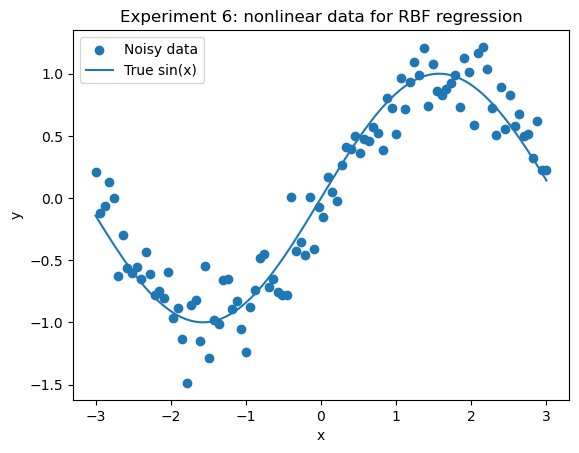

In [8]:
fig, ax = plt.subplots()

ax.scatter(x, y, label="Noisy data")
ax.plot(x, y_clean, label="True sin(x)")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 6: nonlinear data for RBF regression")
ax.legend()

fig_path = FIGURE_DIR / "exp6_raw_data.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [10]:
indices = np.random.permutation(N)
indices

array([19,  6, 45, 57, 22, 25, 48, 30, 59, 73, 15, 12, 49, 95, 14, 50, 89,
       42, 52, 36,  4, 78, 74, 47, 68, 17, 83,  8, 16, 88, 75, 80, 72,  0,
        5, 60, 81, 84, 34, 33, 21, 93,  7, 66, 94, 98, 96, 63, 82, 26, 62,
       58, 65, 90, 55,  9, 39, 77, 86, 29, 64, 20, 46, 51, 53, 23, 27,  2,
       28, 37, 87, 10, 97, 99, 43, 69, 61, 35, 76,  3, 67, 92, 44,  1, 38,
       11, 91, 54, 40, 18, 41, 79, 24, 56, 71, 13, 31, 85, 70, 32])

In [12]:
n_train = int(0.6 * N)
n_val = int(0.2 * N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

x_train = x[train_idx]
y_train = y[train_idx]

x_val = x[val_idx]
y_val = y[val_idx]

x_test = x[test_idx]
y_test = y[test_idx]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (60,)
y_train shape: (60,)
x_val shape: (20,)
y_val shape: (20,)
x_test shape: (20,)
y_test shape: (20,)


In [16]:
def make_rbf_features(x_values, centres, sigma):
    """
    Construct Gaussian RBF design matrix.

    Phi[i,j] = exp(- (x_i-c_j)^2/(2sigma^2))

    x_values shape: (N,)
    centres shape: (M,)
    returned Phi shape: (N,M)
    """
    x_values = np.asarray(x_values)
    centres = np.asarray(centres)

    diff = x_values[:,None] - centres[None,:]
    Phi = np.exp(-(diff**2)/(2*sigma**2))

    return Phi

In [30]:
M_demo = 10
sigma_demo = 0.5

centres_demo = np.linspace(-3,3,M_demo)

Phi_demo = make_rbf_features(x_train, centres_demo, sigma_demo)

print("x_train shape:", x_train.shape)
print("centres_demo shape:", centres_demo.shape)
print("Phi_demo shape:", Phi_demo.shape)
Phi_demo[:5]

x_train shape: (60,)
centres_demo shape: (10,)
Phi_demo shape: (60, 10)


array([[7.05118648e-02, 6.24904709e-01, 9.36022558e-01, 2.36962572e-01,
        1.01389764e-02, 7.33211715e-05, 8.96160087e-08, 1.85123998e-11,
        6.46339600e-16, 3.81399159e-21],
       [7.67618196e-01, 8.32223097e-01, 1.52494854e-01, 4.72271279e-03,
        2.47200191e-05, 2.18689026e-08, 3.26983696e-12, 8.26315936e-17,
        3.52928784e-22, 2.54770390e-28],
       [3.46274834e-07, 2.05062720e-04, 2.05245393e-02, 3.47201061e-01,
        9.92680728e-01, 4.79688225e-01, 3.91768440e-02, 5.40780169e-04,
        1.26163285e-06, 4.97469134e-10],
       [4.30883441e-11, 1.77457220e-07, 1.23523180e-04, 1.45319594e-02,
        2.88948742e-01, 9.71042777e-01, 5.51539774e-01, 5.29463752e-02,
        8.59046258e-04, 2.35568810e-06],
       [2.85655008e-02, 4.11112291e-01, 1.00000000e+00, 4.11112291e-01,
        2.85655008e-02, 3.35462628e-04, 6.65836147e-07, 2.23363144e-10,
        1.26641655e-14, 1.21356367e-19]])

In [32]:
M_basis = 8
sigma_basis = 0.4

centres_basis = np.linspace(-3,3,M_basis)
x_plot = np.linspace(-3,3,400)

Phi_basis_plot = make_rbf_features(x_plot,centres_basis, sigma_basis)

print("x_plot shape:", x_plot.shape)
print("centres_basis shape:", centres_basis.shape)
print("Phi_basis_plot shape:", Phi_basis_plot.shape)

x_plot shape: (400,)
centres_basis shape: (8,)
Phi_basis_plot shape: (400, 8)


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp6_rbf_basis_functions.png


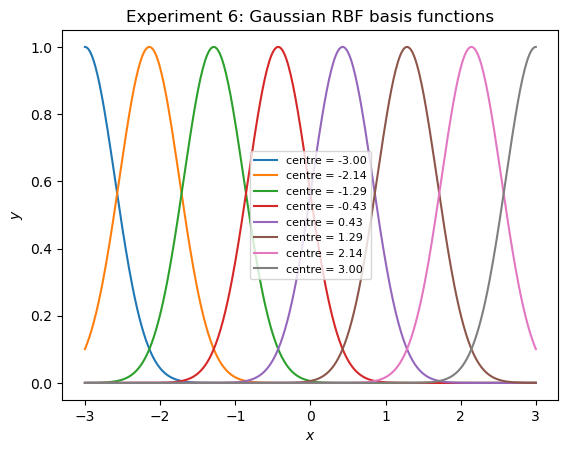

In [36]:
fig, ax = plt.subplots()

for j in range(M_basis):
    ax.plot(x_plot,Phi_basis_plot[:,j],label = f'centre = {centres_basis[j]:.2f}')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Experiment 6: Gaussian RBF basis functions')
ax.legend(fontsize = 8)

fig_path = FIGURE_DIR / 'exp6_rbf_basis_functions.png'
fig.savefig(fig_path, dpi = 200,bbox_inches='tight')

print("Saved figure to:", fig_path)
plt.show()

In [38]:
def mse(y_true,y_pred):
    errors = y_pred - y_true
    return np.mean(errors**2)

In [44]:
def fit_rbf_ridge(Phi, y, reg_strength):
    """
    Fit RBF regression with ridge regularisation.

    For lambda = 0, use ordinary least squares.
    For lambda > 0, solve:
        ((Phi.T @ Phi)/N + lambda I) alpha = (Phi.T @ y) / N
    """
    n_samples, n_features = Phi.shape

    if reg_strength == 0.0:
        alpha_hat, residuals, rank, singular_values = np.linalg.lstsq(Phi, y, rcond = None)
        return alpha_hat

    A = (Phi.T @ Phi) / n_samples + reg_strength * np.eye(n_features)
    rhs = (Phi.T @ y) / n_samples

    alpha_hat = np.linalg.solve(A,rhs)

    return alpha_hat

In [46]:
M = 20
sigma = 0.4
reg_strength = 1e-3

centres = np.linspace(-3, 3, M)

Phi_train = make_rbf_features(x_train, centres, sigma)
Phi_val = make_rbf_features(x_val, centres, sigma)
Phi_test = make_rbf_features(x_test, centres, sigma)

alpha_hat = fit_rbf_ridge(Phi_train, y_train, reg_strength)

y_pred_train = Phi_train @ alpha_hat
y_pred_val = Phi_val @ alpha_hat
y_pred_test = Phi_test @ alpha_hat

train_mse = mse(y_train, y_pred_train)
val_mse = mse(y_val, y_pred_val)
test_mse = mse(y_test, y_pred_test)

print("centres shape:", centres.shape)
print("Phi_train shape:", Phi_train.shape)
print("Phi_val shape:", Phi_val.shape)
print("Phi_test shape:", Phi_test.shape)
print("alpha_hat shape:", alpha_hat.shape)

print("\nMSE values:")
print("Train MSE:", train_mse)
print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)

centres shape: (20,)
Phi_train shape: (60, 20)
Phi_val shape: (20, 20)
Phi_test shape: (20, 20)
alpha_hat shape: (20,)

MSE values:
Train MSE: 0.02738962840843095
Validation MSE: 0.05858624509494555
Test MSE: 0.033920216250836764


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp6_rbf_fit.png


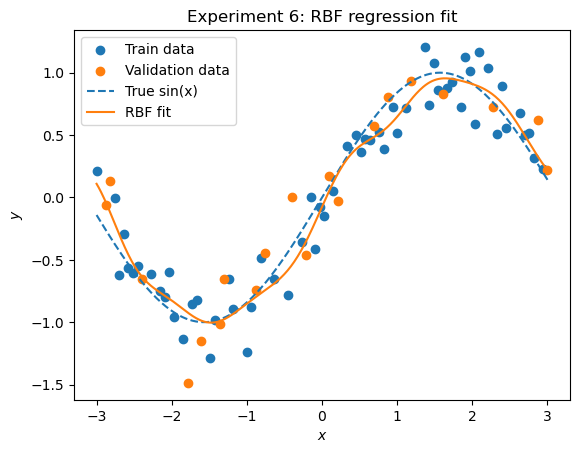

In [50]:
x_plot = np.linspace(-3, 3, 400)
y_clean_plot = np.sin(x_plot)

Phi_plot = make_rbf_features(x_plot, centres, sigma)
y_plot = Phi_plot @ alpha_hat

fig, ax = plt.subplots()

ax.scatter(x_train, y_train, label="Train data")
ax.scatter(x_val, y_val, label="Validation data")
ax.plot(x_plot, y_clean_plot, linestyle="--", label="True sin(x)")
ax.plot(x_plot, y_plot, label="RBF fit")

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Experiment 6: RBF regression fit")
ax.legend()

fig_path = FIGURE_DIR / "exp6_rbf_fit.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [52]:
M_values = [5, 10, 20, 40]
sigma_fixed = 0.4
lambda_fixed = 1e-3

M_results = {}

for M_value in M_values:
    centres_M = np.linspace(-3, 3, M_value)

    Phi_train_M = make_rbf_features(x_train, centres_M, sigma_fixed)
    Phi_val_M = make_rbf_features(x_val, centres_M, sigma_fixed)

    alpha_M = fit_rbf_ridge(Phi_train_M, y_train, lambda_fixed)

    y_pred_train_M = Phi_train_M @ alpha_M
    y_pred_val_M = Phi_val_M @ alpha_M

    train_mse_M = mse(y_train, y_pred_train_M)
    val_mse_M = mse(y_val, y_pred_val_M)

    M_results[M_value] = {
        "centres": centres_M,
        "alpha": alpha_M,
        "train_mse": train_mse_M,
        "val_mse": val_mse_M,
    }

    print("M:", M_value)
    print("  Phi_train shape:", Phi_train_M.shape)
    print("  alpha shape:", alpha_M.shape)
    print("  Train MSE:", train_mse_M)
    print("  Validation MSE:", val_mse_M)
    print()

M: 5
  Phi_train shape: (60, 5)
  alpha shape: (5,)
  Train MSE: 0.11549979054929314
  Validation MSE: 0.11247327014017298

M: 10
  Phi_train shape: (60, 10)
  alpha shape: (10,)
  Train MSE: 0.02933574300570605
  Validation MSE: 0.05697253388146596

M: 20
  Phi_train shape: (60, 20)
  alpha shape: (20,)
  Train MSE: 0.02738962840843095
  Validation MSE: 0.05858624509494555

M: 40
  Phi_train shape: (60, 40)
  alpha shape: (40,)
  Train MSE: 0.02715064967392573
  Validation MSE: 0.05864047849575904



Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp6_effect_of_M.png


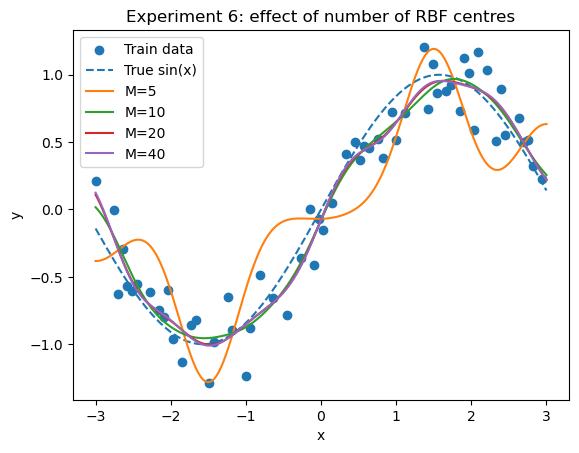

In [54]:
fig, ax = plt.subplots()

ax.scatter(x_train, y_train, label="Train data")
ax.plot(x_plot, y_clean_plot, linestyle="--", label="True sin(x)")

for M_value in M_values:
    centres_M = M_results[M_value]["centres"]
    alpha_M = M_results[M_value]["alpha"]

    Phi_plot_M = make_rbf_features(x_plot, centres_M, sigma_fixed)
    y_plot_M = Phi_plot_M @ alpha_M

    ax.plot(x_plot, y_plot_M, label=f"M={M_value}")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 6: effect of number of RBF centres")
ax.legend()

fig_path = FIGURE_DIR / "exp6_effect_of_M.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [58]:
M_values = [5, 10, 20, 40]
sigma_values = [0.1, 0.2, 0.4, 0.8, 1.6]
lambda_values = [0.0, 1e-6, 1e-3, 1e-1, 1.0]

grid_results = {}

for M_value in M_values:
    centres_grid = np.linspace(-3, 3, M_value)

    for sigma_value in sigma_values:
        Phi_train_grid = make_rbf_features(x_train, centres_grid, sigma_value)
        Phi_val_grid = make_rbf_features(x_val, centres_grid, sigma_value)

        for lambda_value in lambda_values:
            alpha_grid = fit_rbf_ridge(Phi_train_grid, y_train, lambda_value)

            y_pred_train_grid = Phi_train_grid @ alpha_grid
            y_pred_val_grid = Phi_val_grid @ alpha_grid

            train_mse_grid = mse(y_train, y_pred_train_grid)
            val_mse_grid = mse(y_val, y_pred_val_grid)

            key = (M_value, sigma_value, lambda_value)

            grid_results[key] = {
                "centres": centres_grid,
                "alpha": alpha_grid,
                "train_mse": train_mse_grid,
                "val_mse": val_mse_grid,
            }

print("Number of models fitted:", len(grid_results))
4*5*5

Number of models fitted: 100


100

In [60]:
best_key = min(
    grid_results.keys(),
    key=lambda key: grid_results[key]["val_mse"]
)

best_M, best_sigma, best_lambda = best_key

print("Best hyperparameters by validation MSE:")
print("M:", best_M)
print("sigma:", best_sigma)
print("lambda:", best_lambda)

print("\nBest train MSE:", grid_results[best_key]["train_mse"])
print("Best validation MSE:", grid_results[best_key]["val_mse"])

Best hyperparameters by validation MSE:
M: 40
sigma: 1.6
lambda: 1e-06

Best train MSE: 0.02979690419063756
Best validation MSE: 0.04934034311782248


In [62]:
heatmap_M = 20

heatmap_values = np.zeros((len(sigma_values), len(lambda_values)))

for i, sigma_value in enumerate(sigma_values):
    for j, lambda_value in enumerate(lambda_values):
        key = (heatmap_M, sigma_value, lambda_value)
        heatmap_values[i, j] = grid_results[key]["val_mse"]

print("heatmap_values shape:", heatmap_values.shape)
print(heatmap_values)

heatmap_values shape: (5, 5)
[[0.08487007 0.08487069 0.08595155 0.33123063 0.47222035]
 [0.05980783 0.05980666 0.0588964  0.14869043 0.40652316]
 [0.05568981 0.05596121 0.05858625 0.07167787 0.26916319]
 [0.06819855 0.05696058 0.05309056 0.06590634 0.15661658]
 [0.05909234 0.04937189 0.06030716 0.11277644 0.17611035]]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp6_validation_mse_heatmap_M=20.png


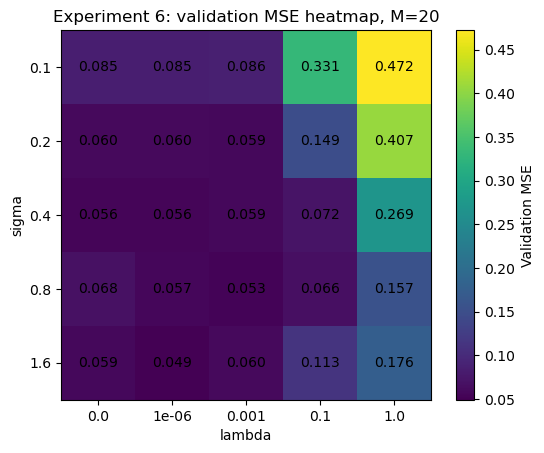

In [64]:
fig, ax = plt.subplots()

image = ax.imshow(heatmap_values)

ax.set_xticks(np.arange(len(lambda_values)))
ax.set_yticks(np.arange(len(sigma_values)))

ax.set_xticklabels([str(value) for value in lambda_values])
ax.set_yticklabels([str(value) for value in sigma_values])

ax.set_xlabel("lambda")
ax.set_ylabel("sigma")
ax.set_title("Experiment 6: validation MSE heatmap, M=20")

for i in range(len(sigma_values)):
    for j in range(len(lambda_values)):
        ax.text(j, i, f"{heatmap_values[i, j]:.3f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Validation MSE")

fig_path = FIGURE_DIR / "exp6_validation_mse_heatmap_M=20.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

heatmap_values shape: (5, 5)
[[ 0.12608199  0.12564307  0.07246617  0.23280509  0.44717337]
 [ 0.08123199  0.06604431  0.05953089  0.09299965  0.33923232]
 [16.42638132  0.05580127  0.05864048  0.06098524  0.17934624]
 [ 0.20786007  0.05703665  0.05362798  0.06175825  0.10389731]
 [ 0.0590543   0.04934034  0.05973612  0.0984336   0.14429075]]
Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp6_validation_mse_heatmap_M=40.png


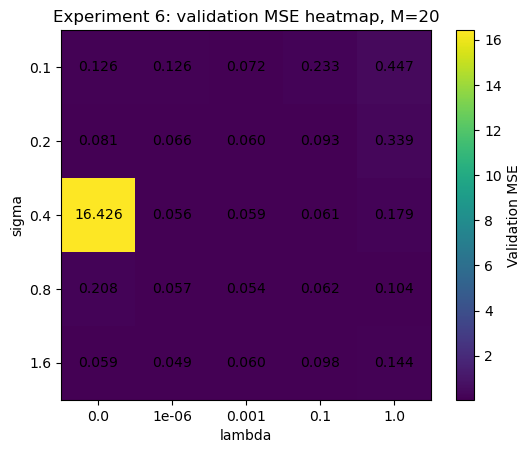

In [69]:
heatmap_M = 40

heatmap_values = np.zeros((len(sigma_values), len(lambda_values)))

for i, sigma_value in enumerate(sigma_values):
    for j, lambda_value in enumerate(lambda_values):
        key = (heatmap_M, sigma_value, lambda_value)
        heatmap_values[i, j] = grid_results[key]["val_mse"]

print("heatmap_values shape:", heatmap_values.shape)
print(heatmap_values)

fig, ax = plt.subplots()

image = ax.imshow(heatmap_values)

ax.set_xticks(np.arange(len(lambda_values)))
ax.set_yticks(np.arange(len(sigma_values)))

ax.set_xticklabels([str(value) for value in lambda_values])
ax.set_yticklabels([str(value) for value in sigma_values])

ax.set_xlabel("lambda")
ax.set_ylabel("sigma")
ax.set_title("Experiment 6: validation MSE heatmap, M=20")

for i in range(len(sigma_values)):
    for j in range(len(lambda_values)):
        ax.text(j, i, f"{heatmap_values[i, j]:.3f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Validation MSE")

fig_path = FIGURE_DIR / "exp6_validation_mse_heatmap_M=40.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [71]:
best_result = grid_results[best_key]

centres_best = best_result["centres"]
alpha_best = best_result["alpha"]

Phi_test_best = make_rbf_features(x_test, centres_best, best_sigma)
y_pred_test_best = Phi_test_best @ alpha_best

test_mse_best = mse(y_test, y_pred_test_best)

print("Best M:", best_M)
print("Best sigma:", best_sigma)
print("Best lambda:", best_lambda)

print("\nPhi_test_best shape:", Phi_test_best.shape)
print("alpha_best shape:", alpha_best.shape)
print("y_pred_test_best shape:", y_pred_test_best.shape)

print("\nTrain MSE:", best_result["train_mse"])
print("Validation MSE:", best_result["val_mse"])
print("Test MSE:", test_mse_best)

Best M: 40
Best sigma: 1.6
Best lambda: 1e-06

Phi_test_best shape: (20, 40)
alpha_best shape: (40,)
y_pred_test_best shape: (20,)

Train MSE: 0.02979690419063756
Validation MSE: 0.04934034311782248
Test MSE: 0.034955786789624695


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp6_best_rbf_model.png


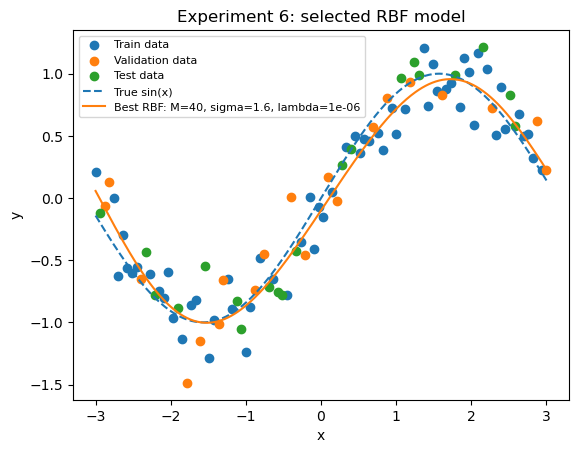

In [73]:
Phi_plot_best = make_rbf_features(x_plot, centres_best, best_sigma)
y_plot_best = Phi_plot_best @ alpha_best

fig, ax = plt.subplots()

ax.scatter(x_train, y_train, label="Train data")
ax.scatter(x_val, y_val, label="Validation data")
ax.scatter(x_test, y_test, label="Test data")

ax.plot(x_plot, y_clean_plot, linestyle="--", label="True sin(x)")
ax.plot(
    x_plot,
    y_plot_best,
    label=f"Best RBF: M={best_M}, sigma={best_sigma}, lambda={best_lambda}"
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 6: selected RBF model")
ax.legend(fontsize=8)

fig_path = FIGURE_DIR / "exp6_best_rbf_model.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp6_prediction_vs_truth.png


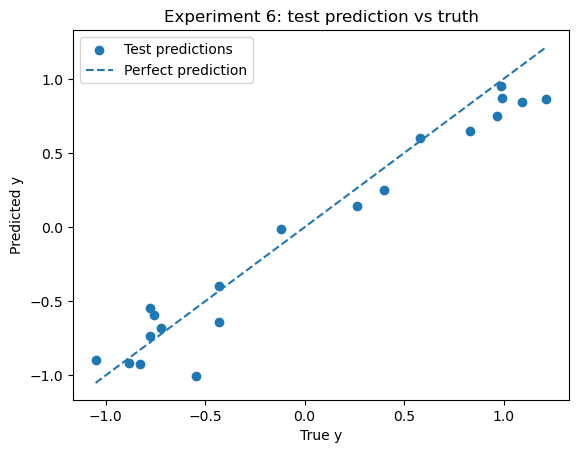

In [75]:
fig, ax = plt.subplots()

ax.scatter(y_test, y_pred_test_best, label="Test predictions")

min_value = min(y_test.min(), y_pred_test_best.min())
max_value = max(y_test.max(), y_pred_test_best.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

ax.set_xlabel("True y")
ax.set_ylabel("Predicted y")
ax.set_title("Experiment 6: test prediction vs truth")
ax.legend()

fig_path = FIGURE_DIR / "exp6_prediction_vs_truth.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()